In [ ]:
!pip install pandas numpy matplotlib scikit-learn joblib

In [ ]:
import pandas as pd
import numpy as np

# Create datetime range (hourly data for 60 days)
date_range = pd.date_range(start="2023-01-01", periods=24*60, freq='H')

# Simulate energy usage pattern
np.random.seed(42)

energy = (
    200
    + 50*np.sin(2 * np.pi * date_range.hour / 24)   # daily cycle
    + 20*np.sin(2 * np.pi * date_range.dayofweek / 7) # weekly pattern
    + 15*np.random.randn(len(date_range))           # noise
)

# Create dataframe
data = pd.DataFrame({
    'Datetime': date_range,
    'Energy': energy
})

# Save dataset
data.to_csv('energy.csv', index=False)

data.head()

/tmp/ipykernel_8623/2403513954.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start="2023-01-01", periods=24*60, freq='H')


,Datetime,Energy
0,2023-01-01 00:00:00,191.814083
1,2023-01-01 01:00:00,195.230358
2,2023-01-01 02:00:00,219.078698
3,2023-01-01 03:00:00,242.564157
4,2023-01-01 04:00:00,224.152340


In [ ]:
data = pd.read_csv('energy.csv', parse_dates=['Datetime'], index_col='Datetime')

data.head()

,Energy
Datetime,
2023-01-01 00:00:00,191.814083
2023-01-01 01:00:00,195.230358
2023-01-01 02:00:00,219.078698
2023-01-01 03:00:00,242.564157
2023-01-01 04:00:00,224.152340


In [ ]:
# Convert to hourly (already hourly but done for practice)
data = data.resample('H').mean()

# Fill missing values
data = data.fillna(method='ffill')

print(data.isnull().sum())

Energy    0
dtype: int64


/tmp/ipykernel_8623/947283695.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data = data.resample('H').mean()
/tmp/ipykernel_8623/947283695.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


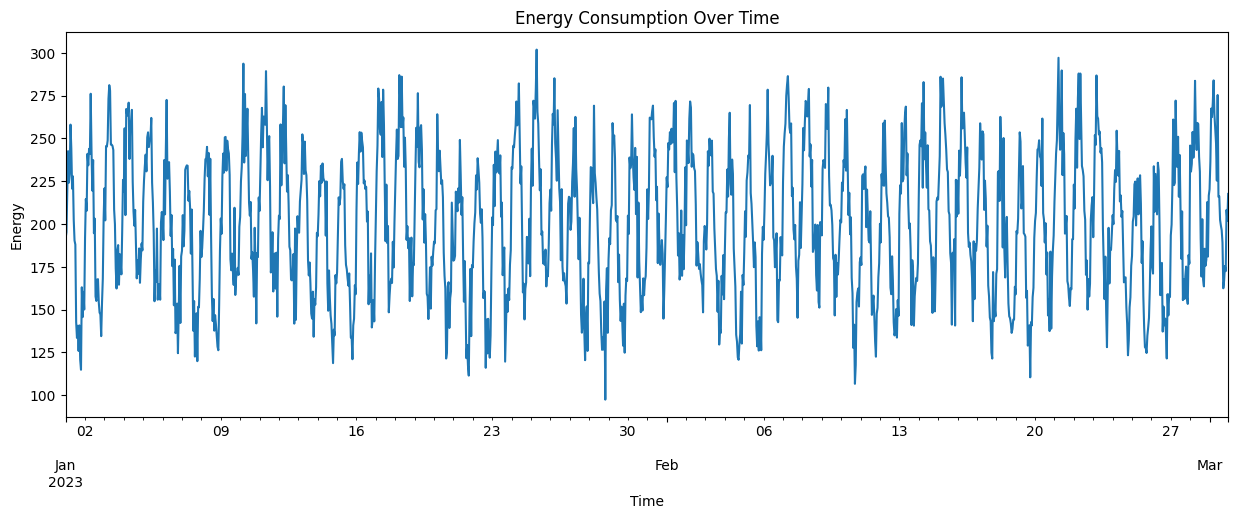

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
data['Energy'].plot(title="Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.show()

In [ ]:
# Extract time-based features
data['hour'] = data.index.hour
data['day'] = data.index.dayofweek
data['month'] = data.index.month

data.head()

,Energy,hour,day,month
Datetime,,,,
2023-01-01 00:00:00,191.814083,0,6,1
2023-01-01 01:00:00,195.230358,1,6,1
2023-01-01 02:00:00,219.078698,2,6,1
2023-01-01 03:00:00,242.564157,3,6,1
2023-01-01 04:00:00,224.152340,4,6,1


In [ ]:
from sklearn.model_selection import train_test_split

X = data[['hour', 'day', 'month']]
y = data['Energy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    max_iter=500,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model Training Completed")

✅ Model Training Completed


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 16.166448770151174
R² Score: 0.77431254144453


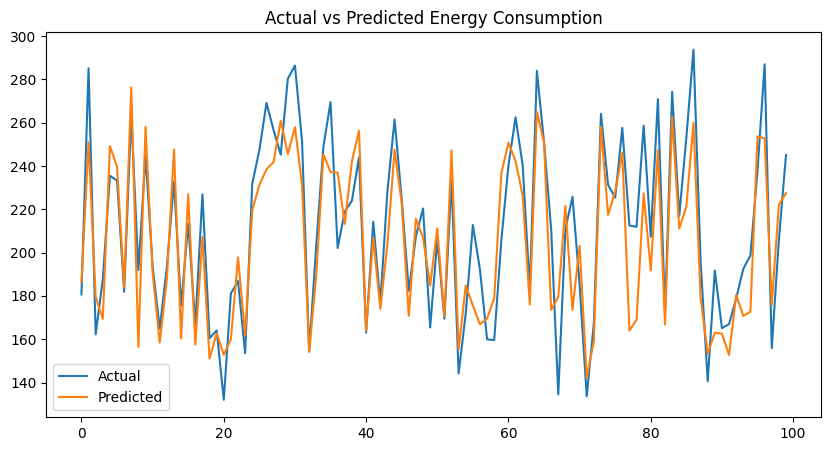

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

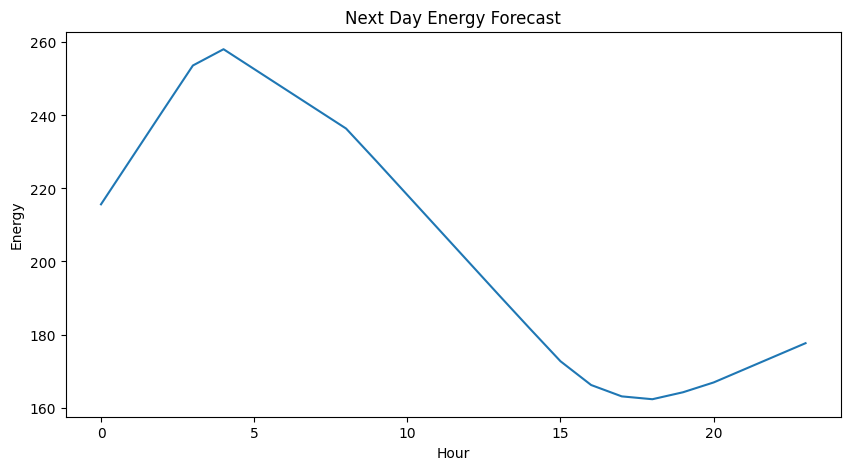

In [ ]:
# Predict next day (24 hours)
future_hours = list(range(24))
future_days = [2]*24   # Wednesday
future_months = [1]*24

future_data = pd.DataFrame({
    'hour': future_hours,
    'day': future_days,
    'month': future_months
})

future_predictions = model.predict(future_data)

plt.figure(figsize=(10,5))
plt.plot(future_hours, future_predictions)
plt.title("Next Day Energy Forecast")
plt.xlabel("Hour")
plt.ylabel("Energy")
plt.show()

In [ ]:
import joblib

joblib.dump(model, 'energy_model.pkl')

print("✅ Model Saved")

✅ Model Saved


In [ ]:
from google.colab import files
files.download('energy_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>